In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set seaborn style directly
sns.set_theme()

# Subir el archivo ("vgsales.csv")
upload = files.upload()

# Cargar el dataset
file_path = "in-vehicle-coupon-recommendation.csv"
df = pd.read_csv(file_path, sep=";")

# Asegurarse de que los nombres de las columnas no tengan espacios extra
df.columns = df.columns.str.strip()

Saving in-vehicle-coupon-recommendation.csv to in-vehicle-coupon-recommendation (2).csv


In [ ]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   

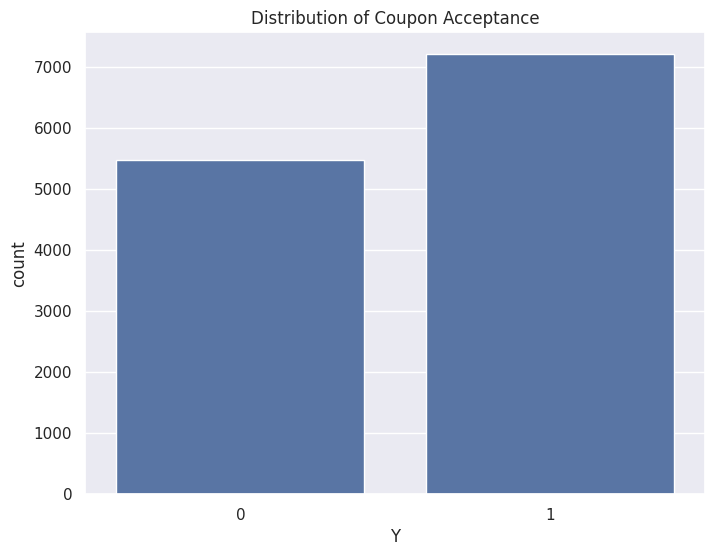

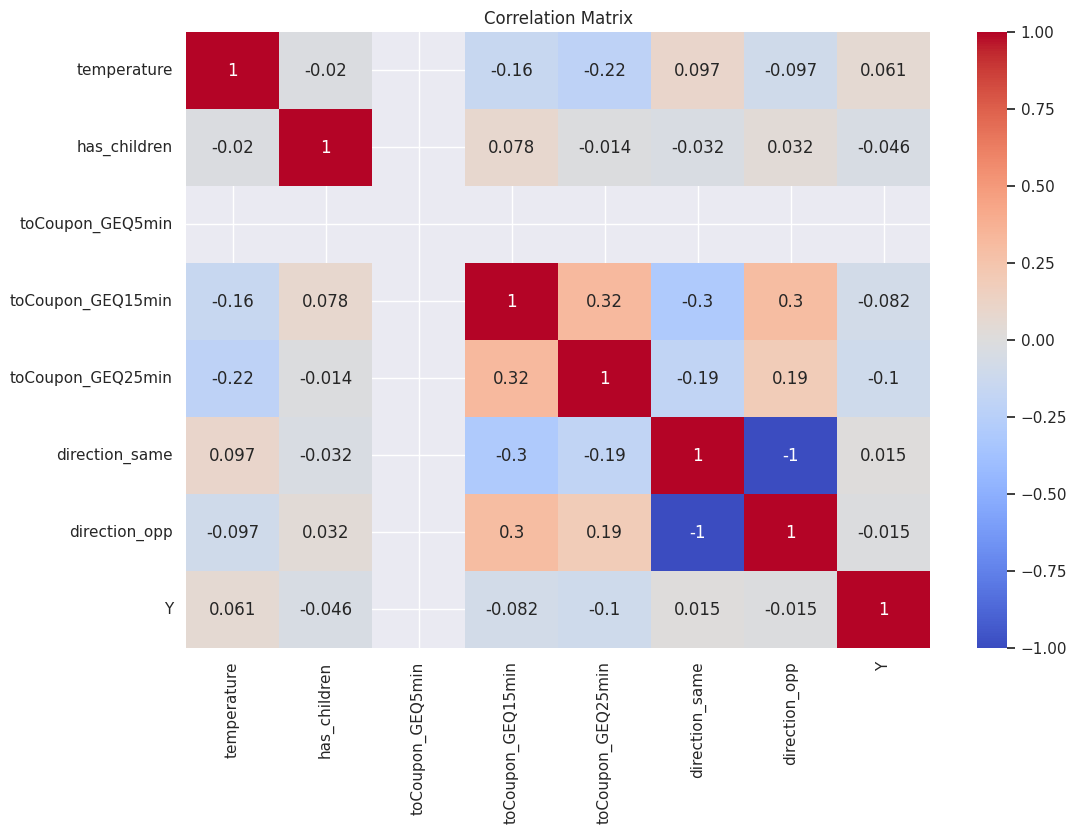

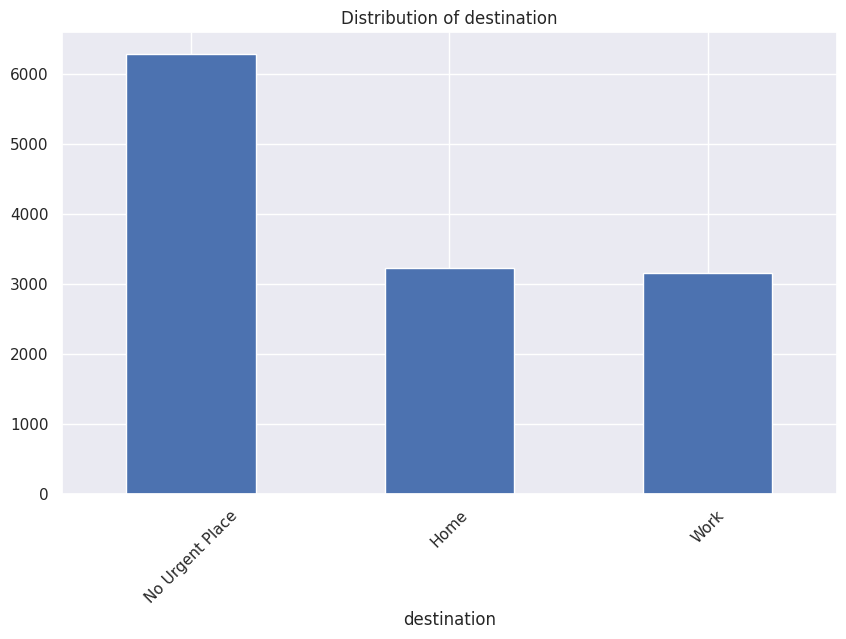

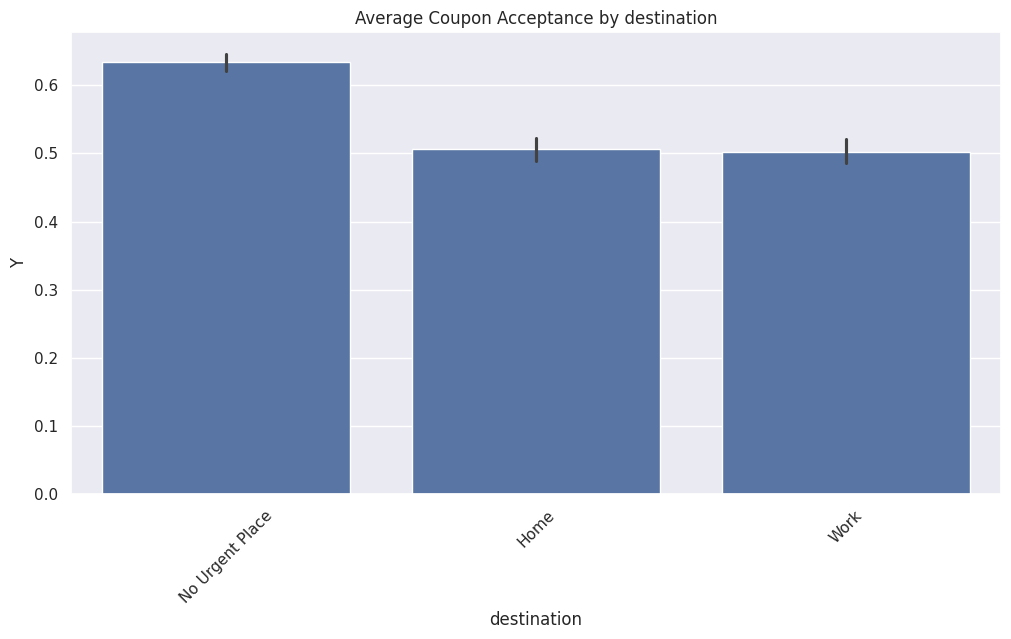

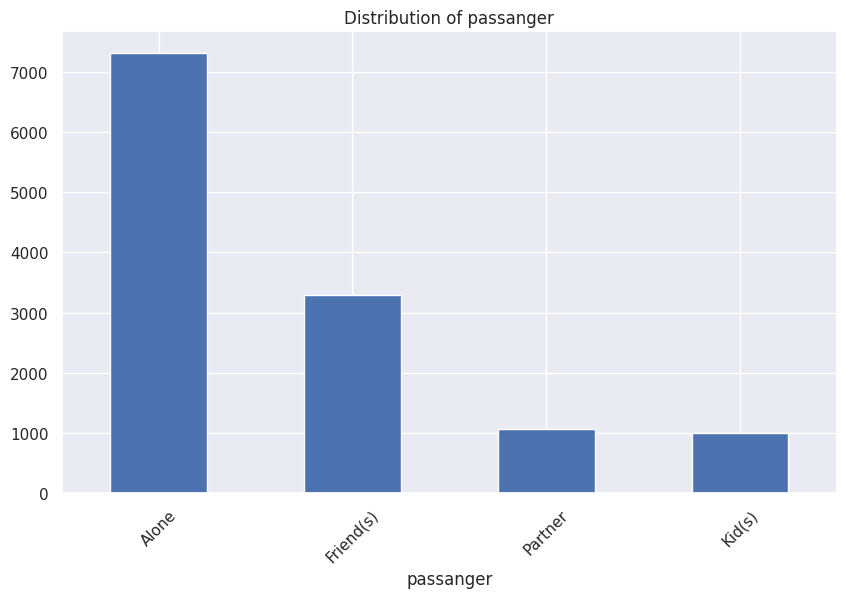

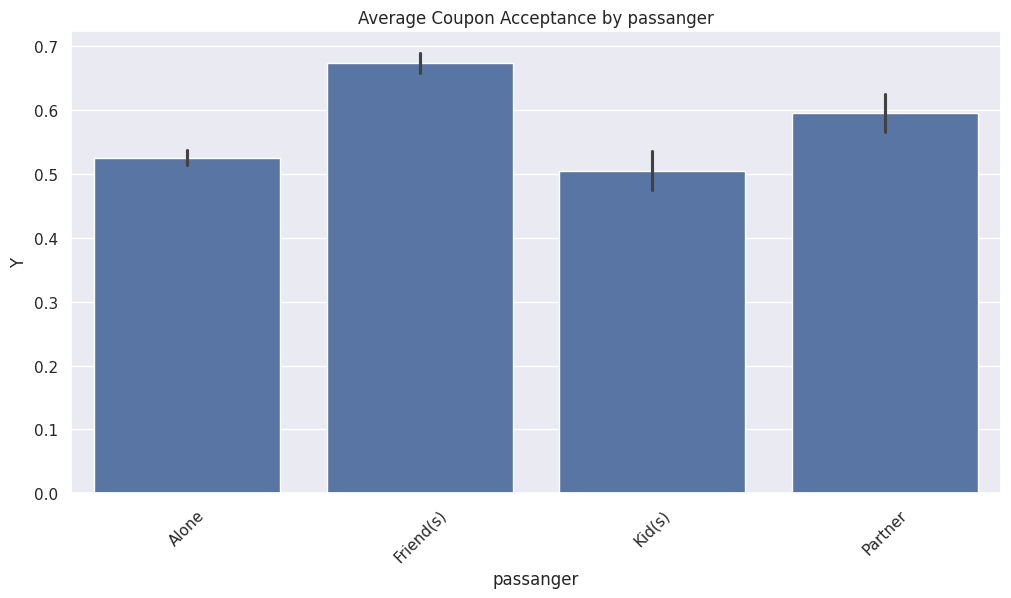

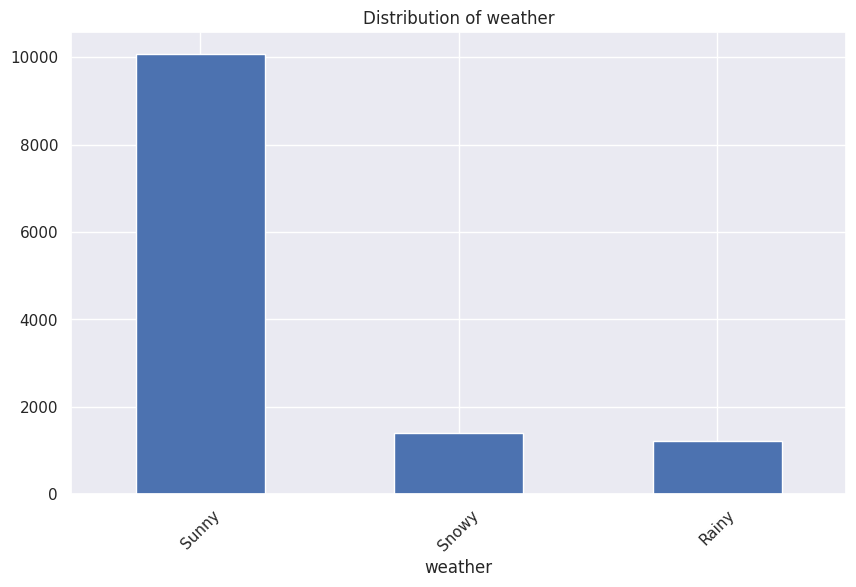

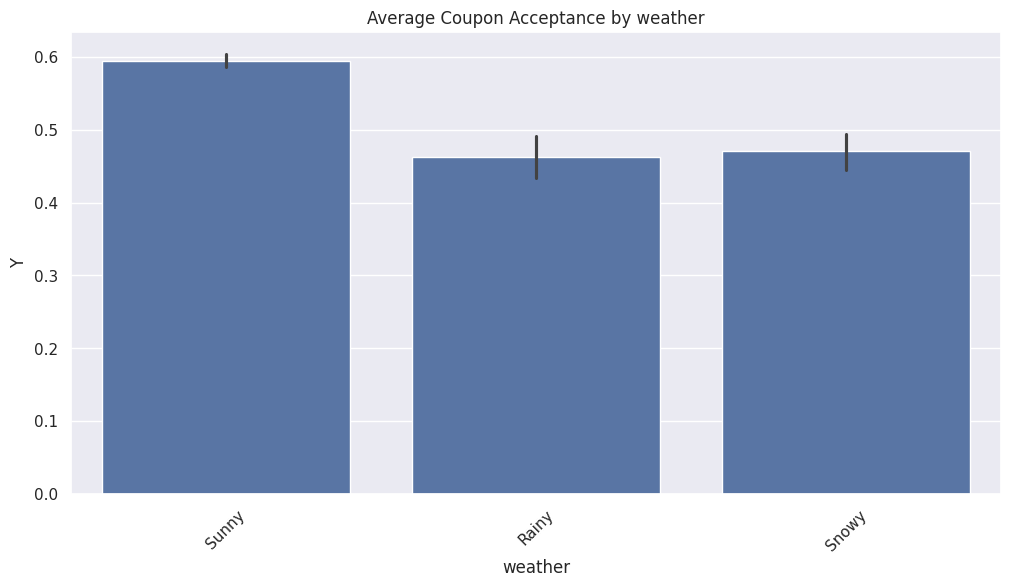

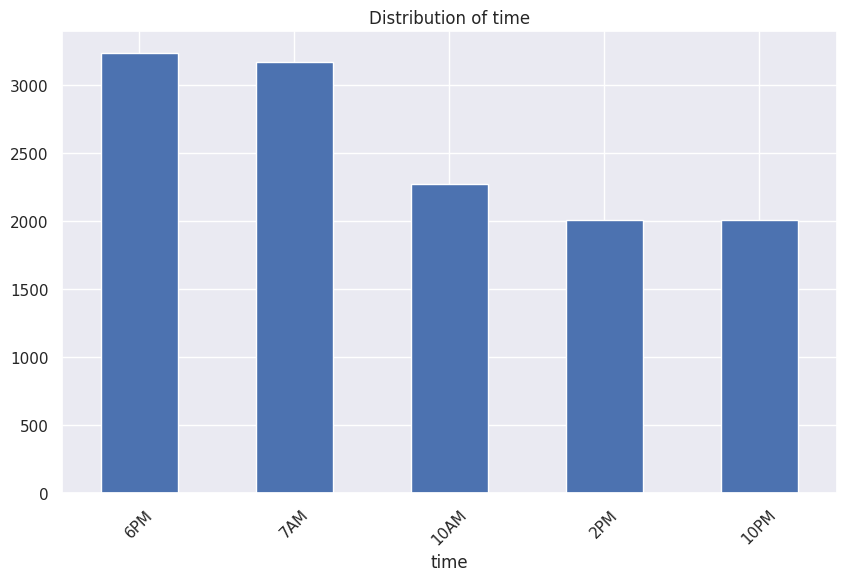

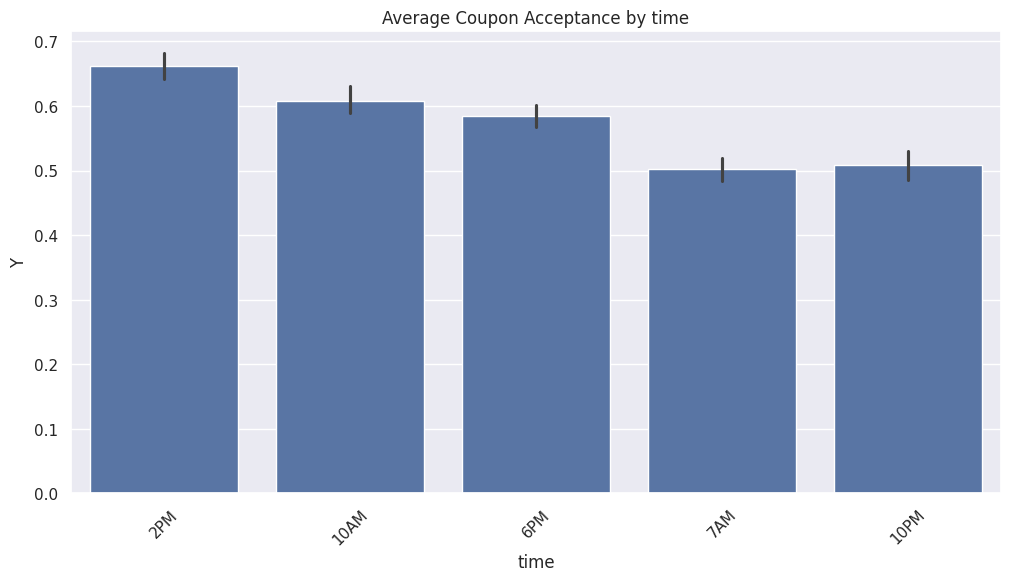

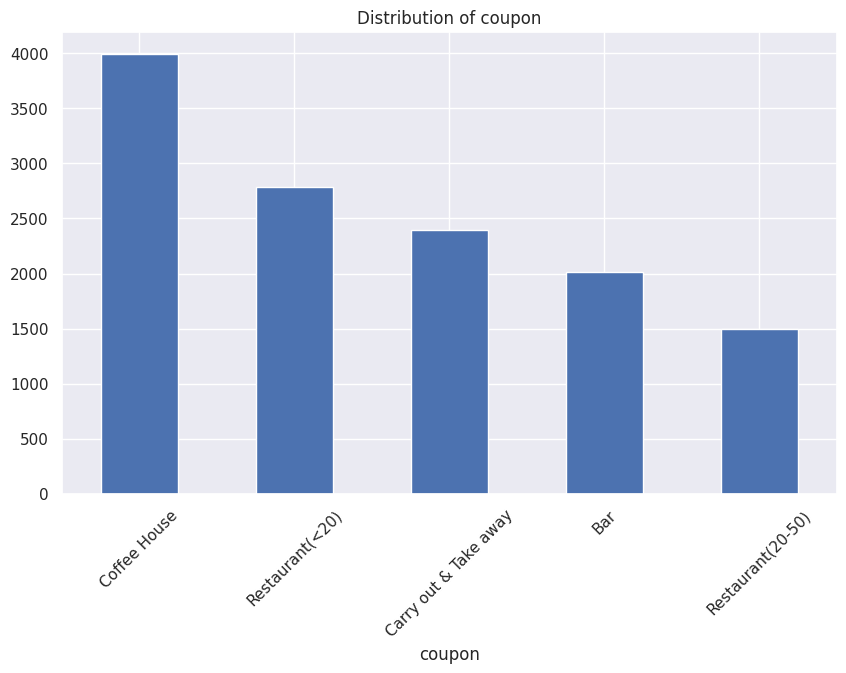

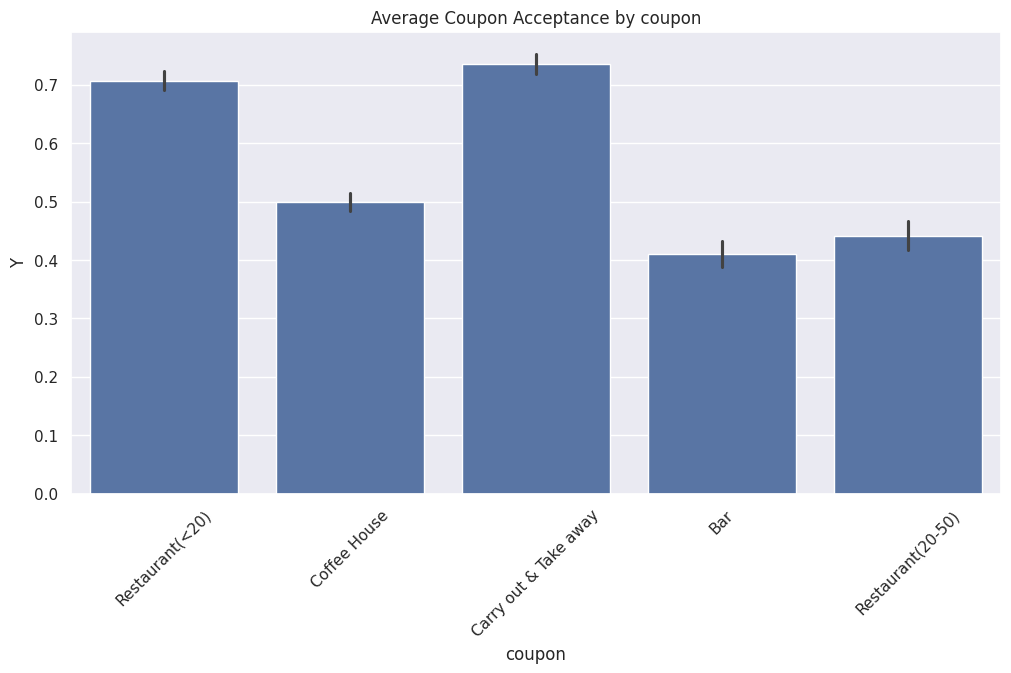

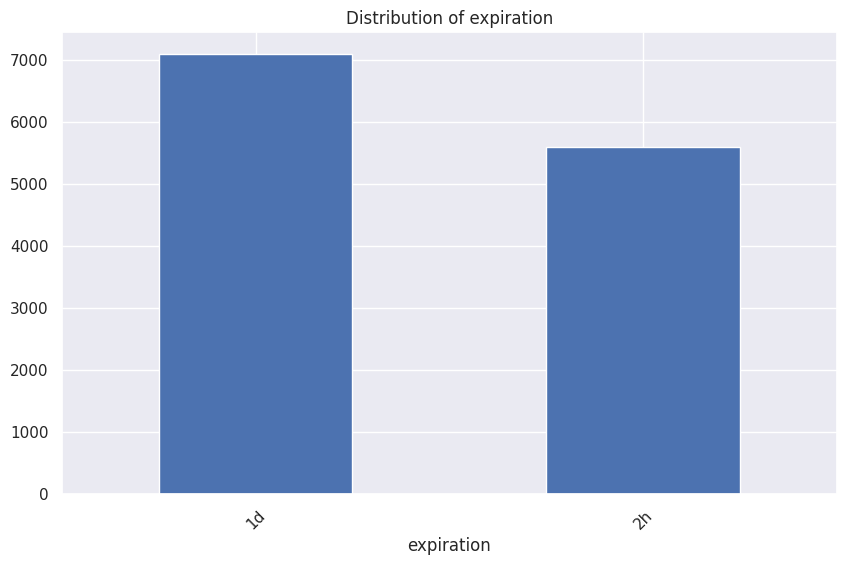

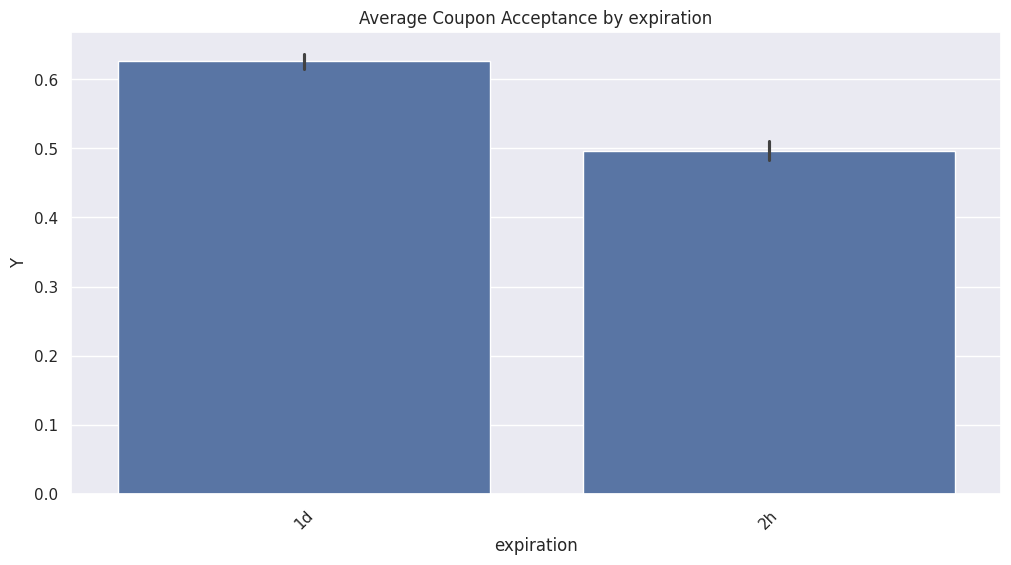

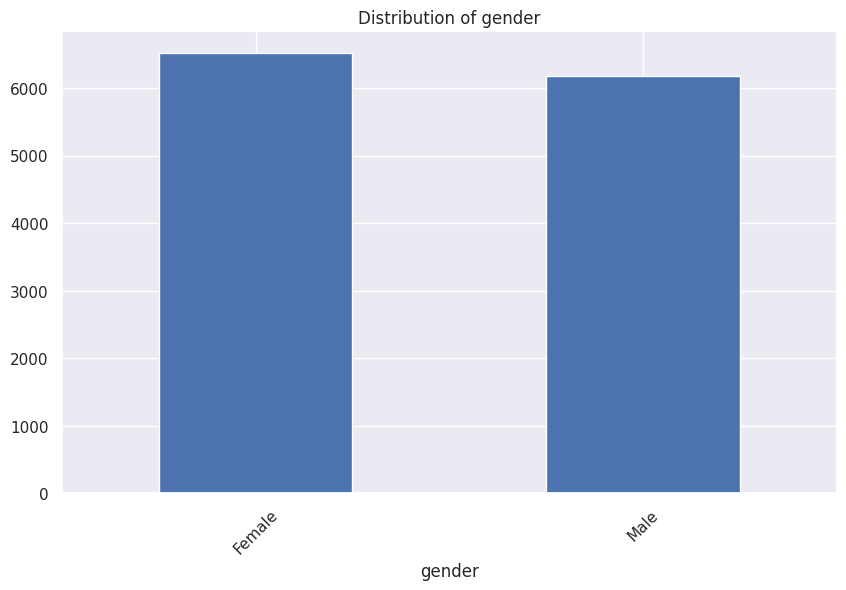

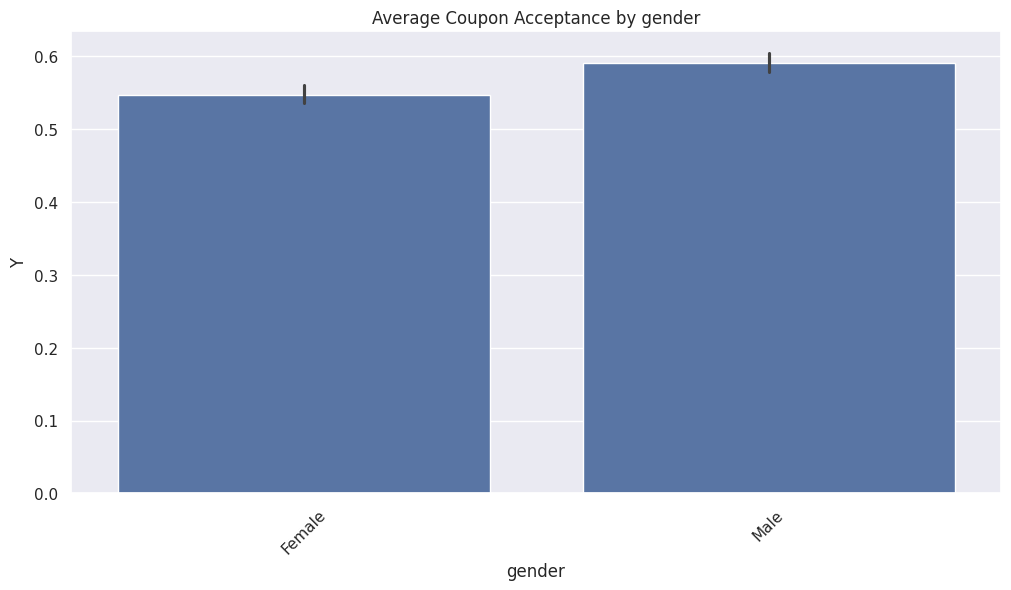

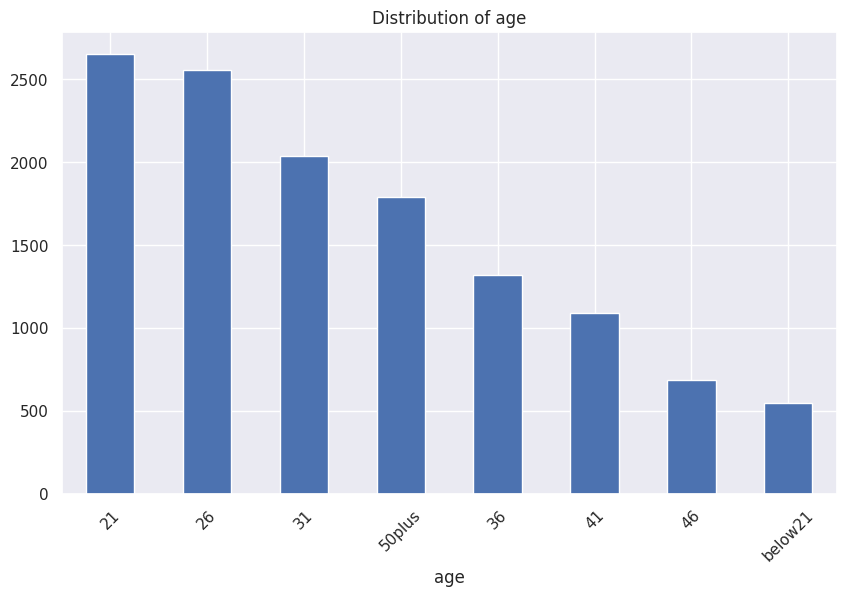

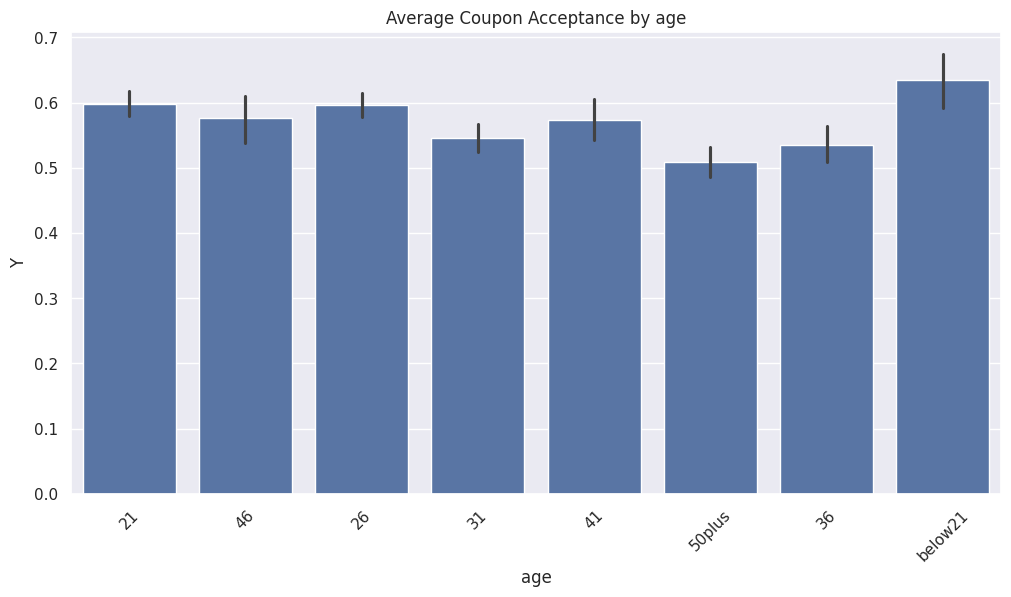

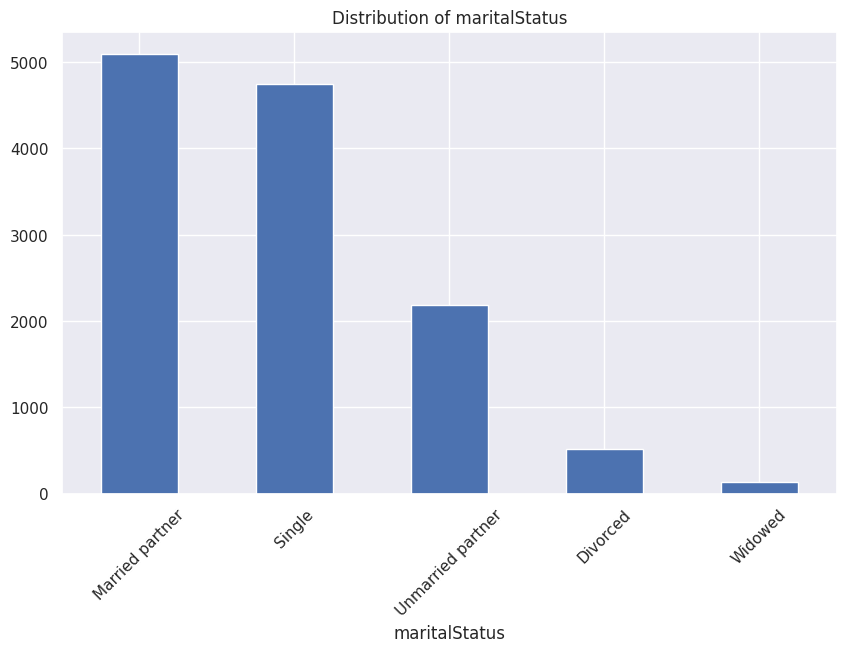

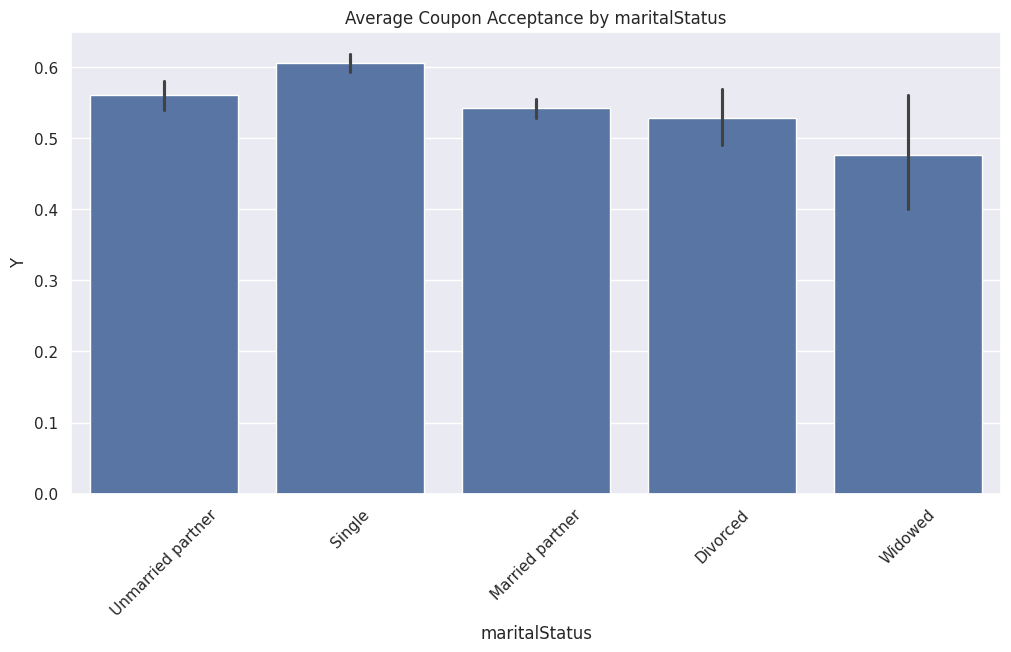

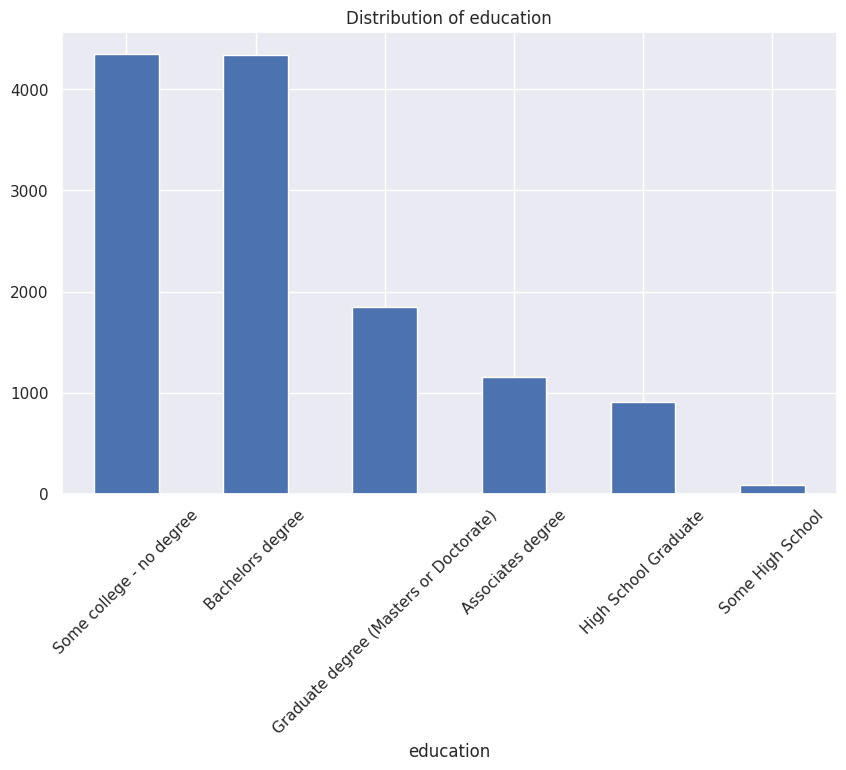

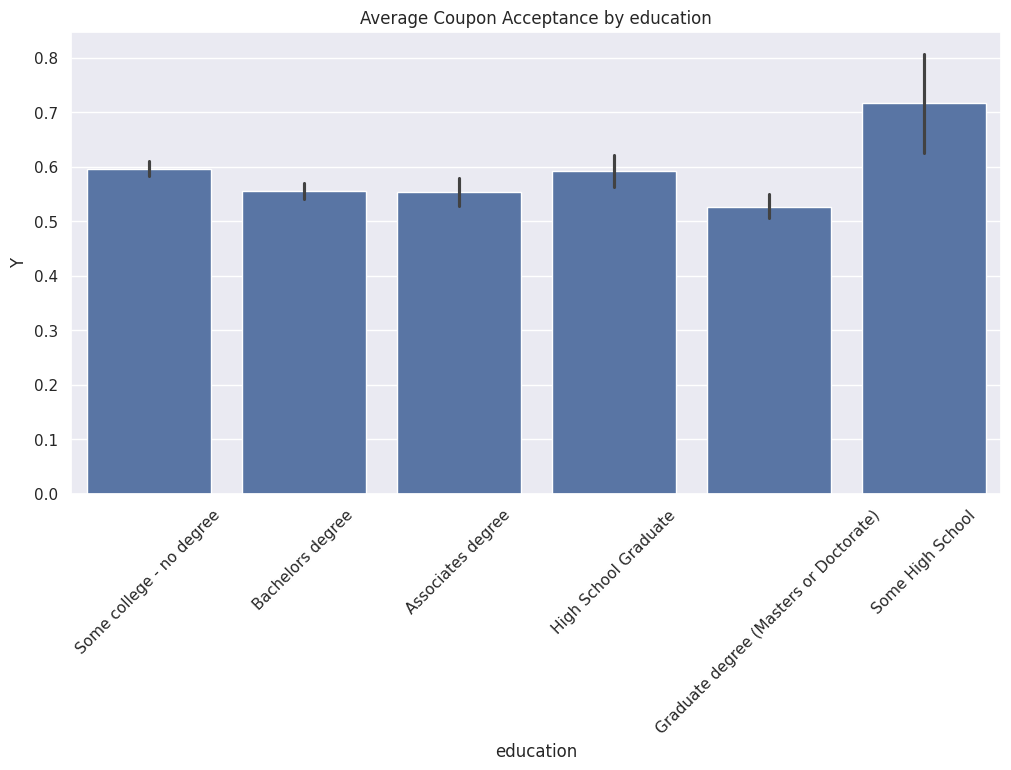

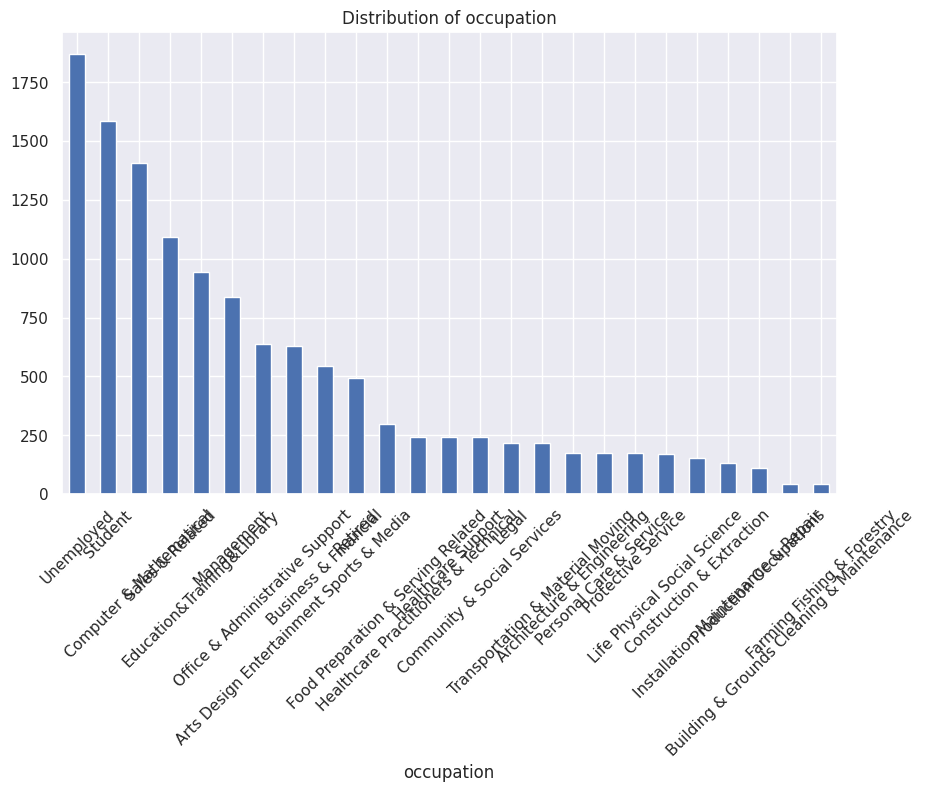

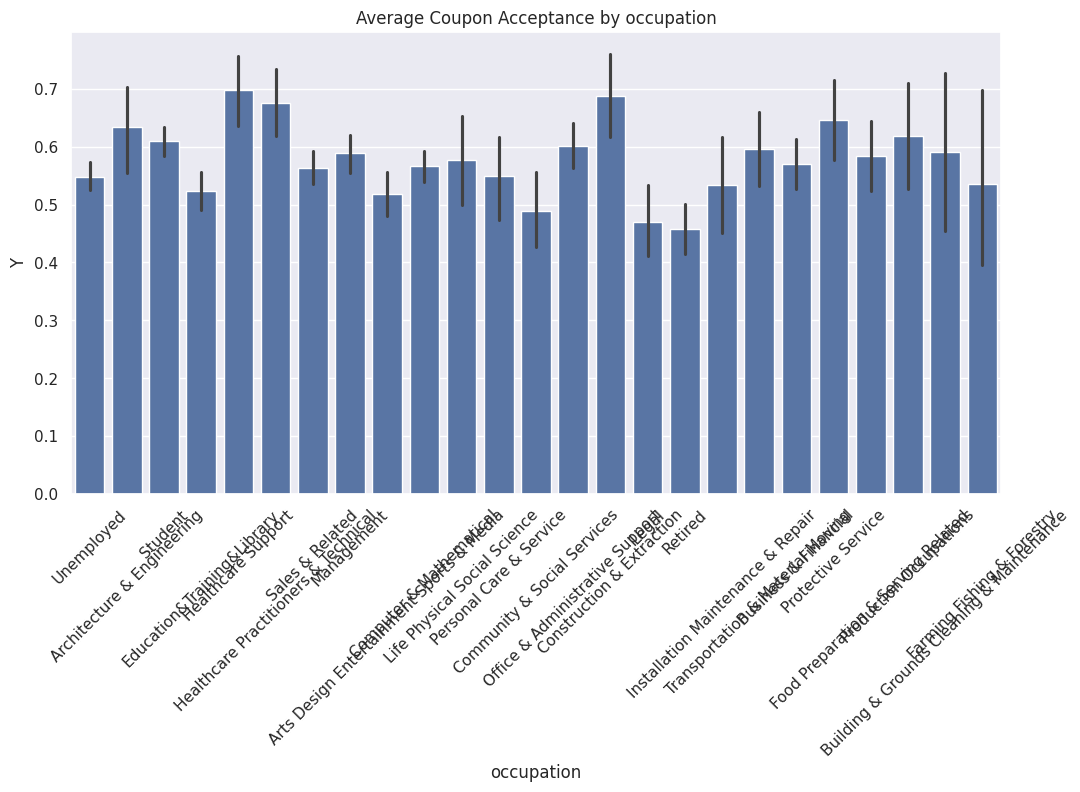

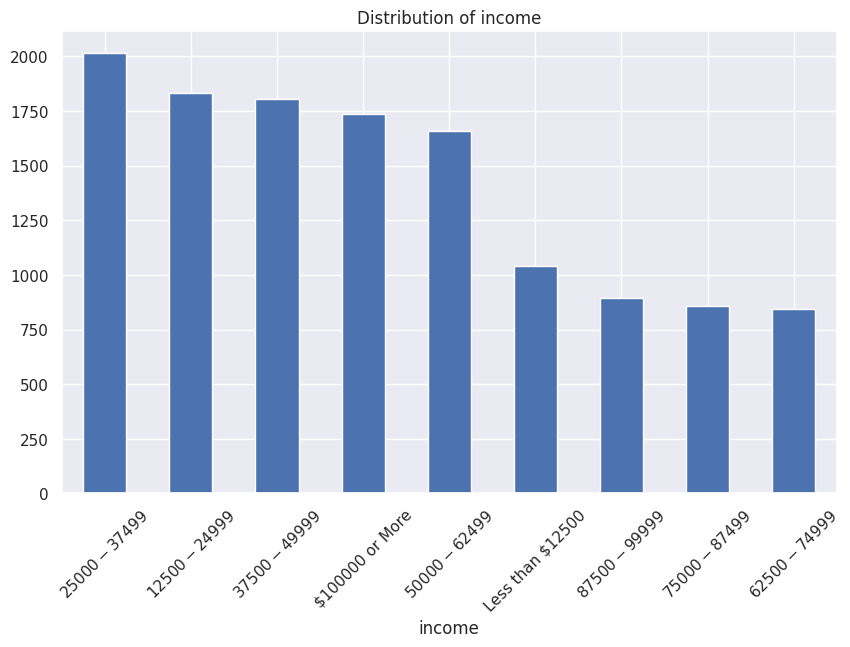

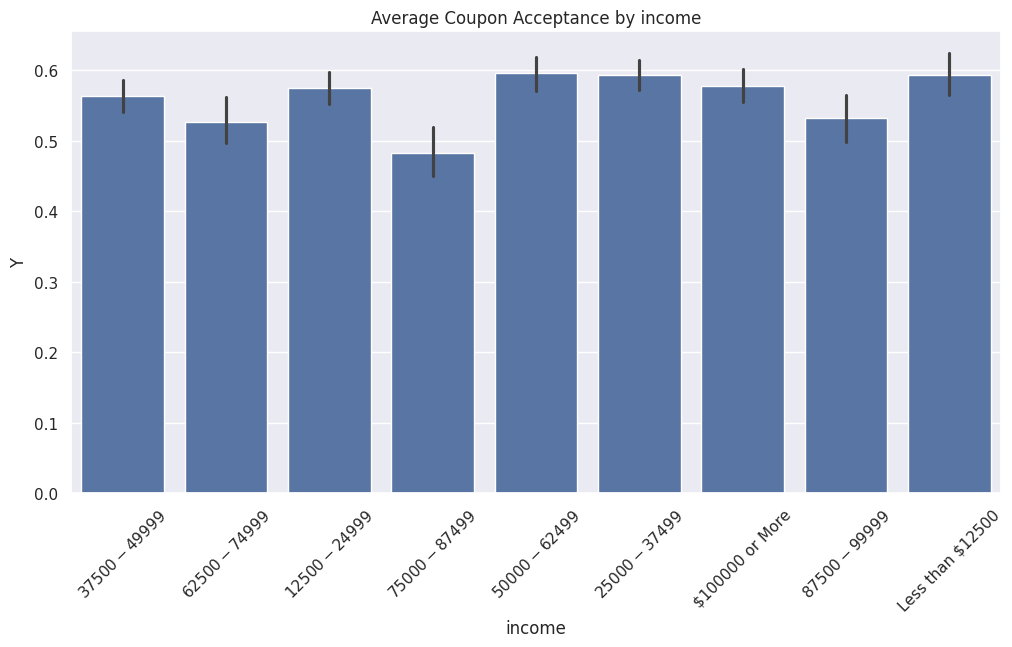

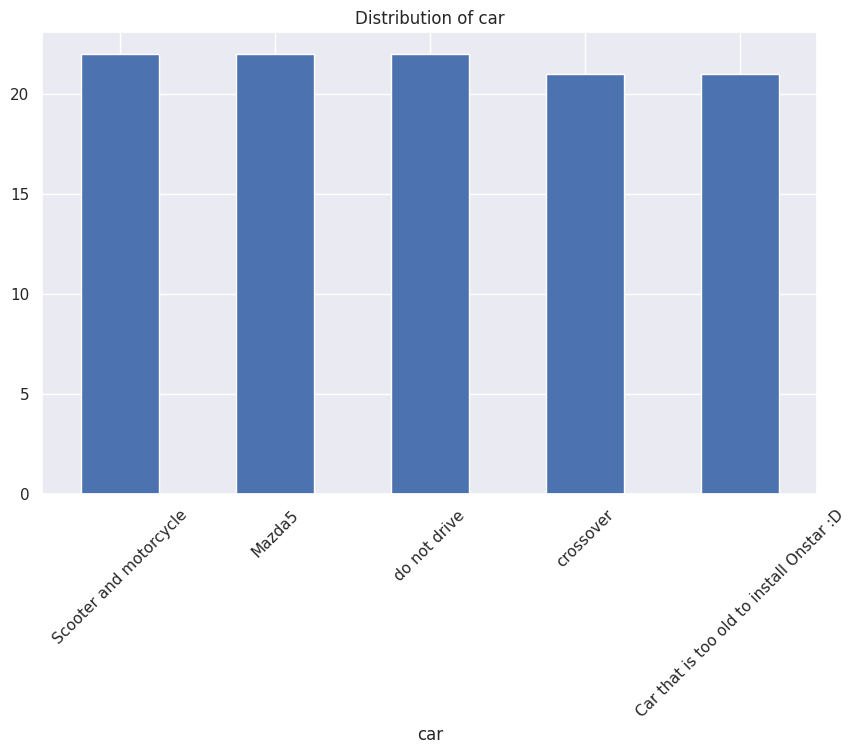

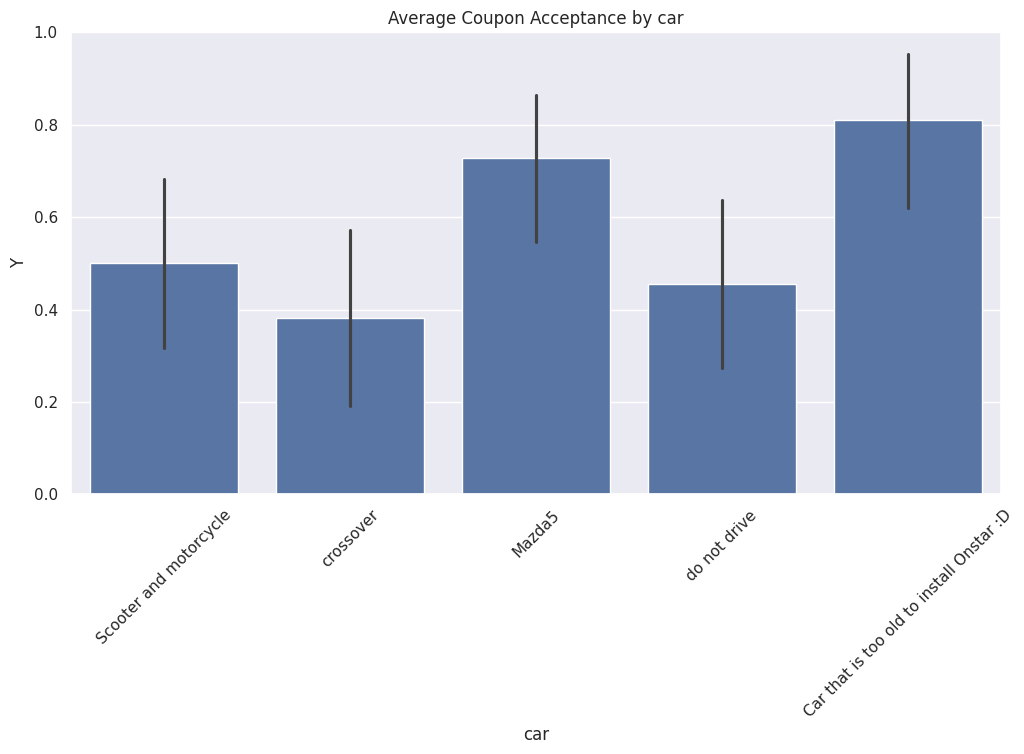

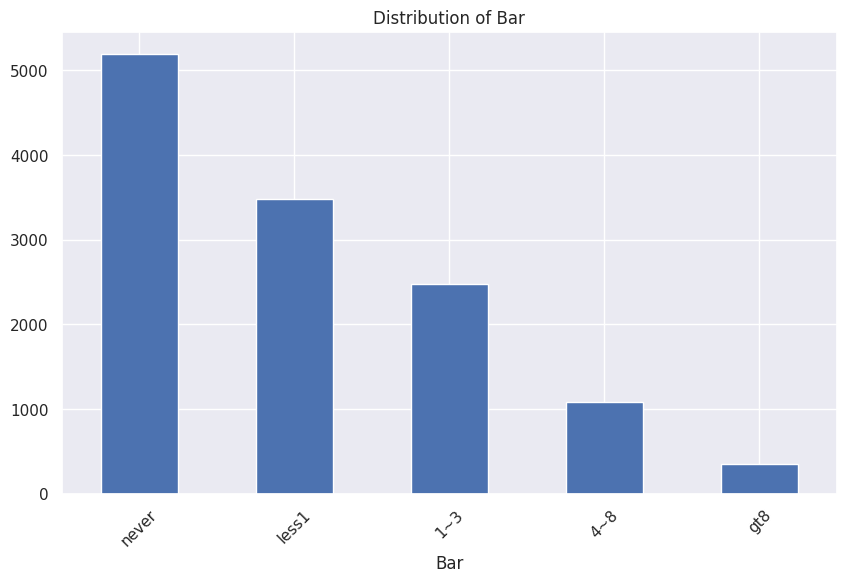

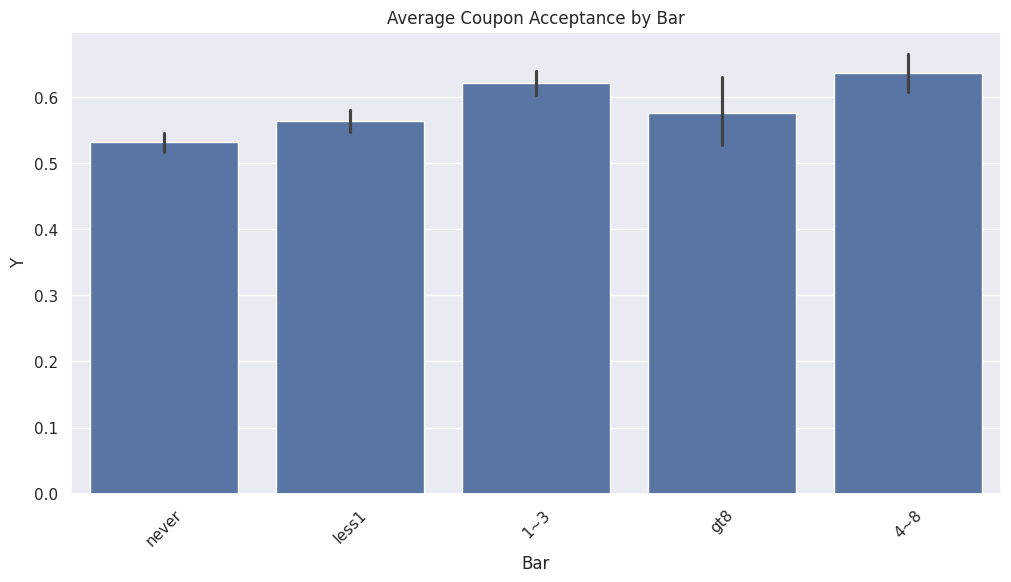

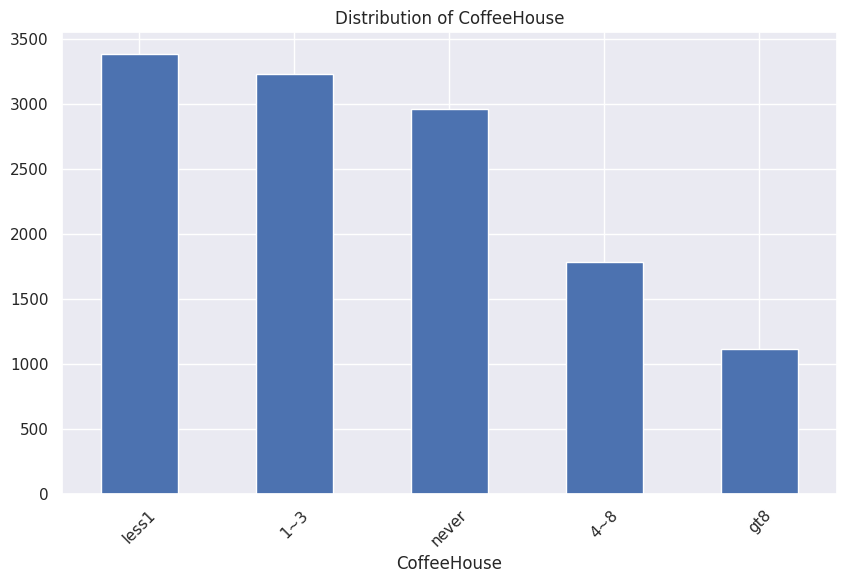

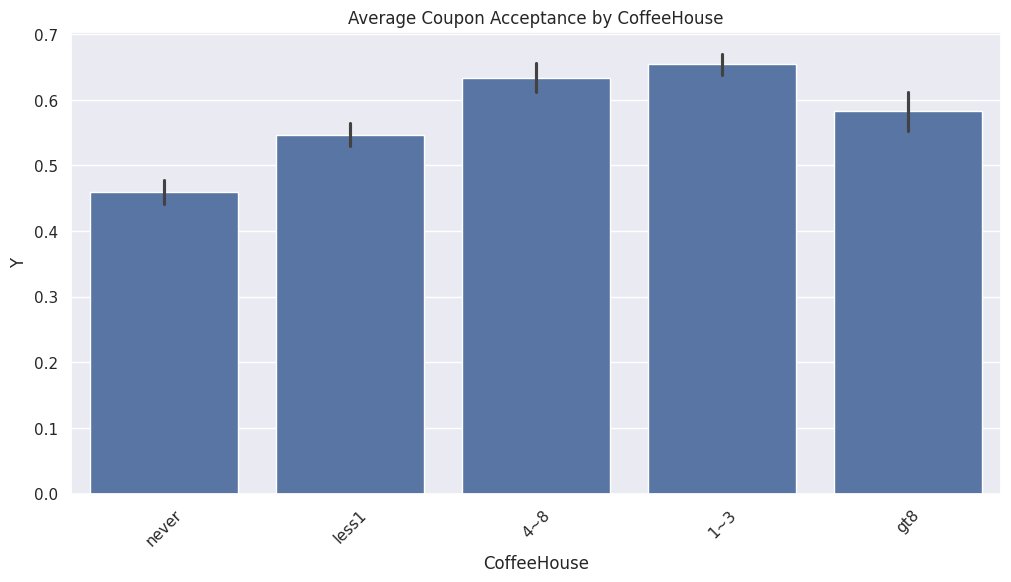

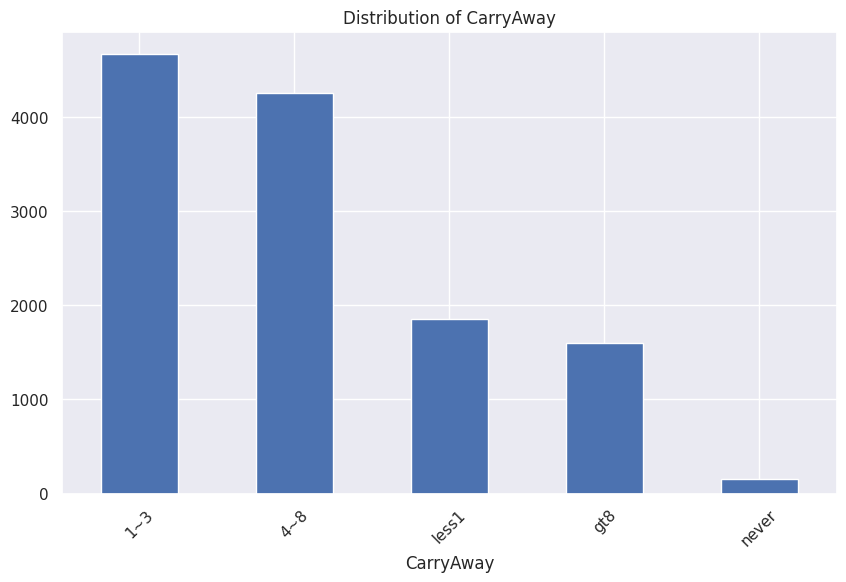

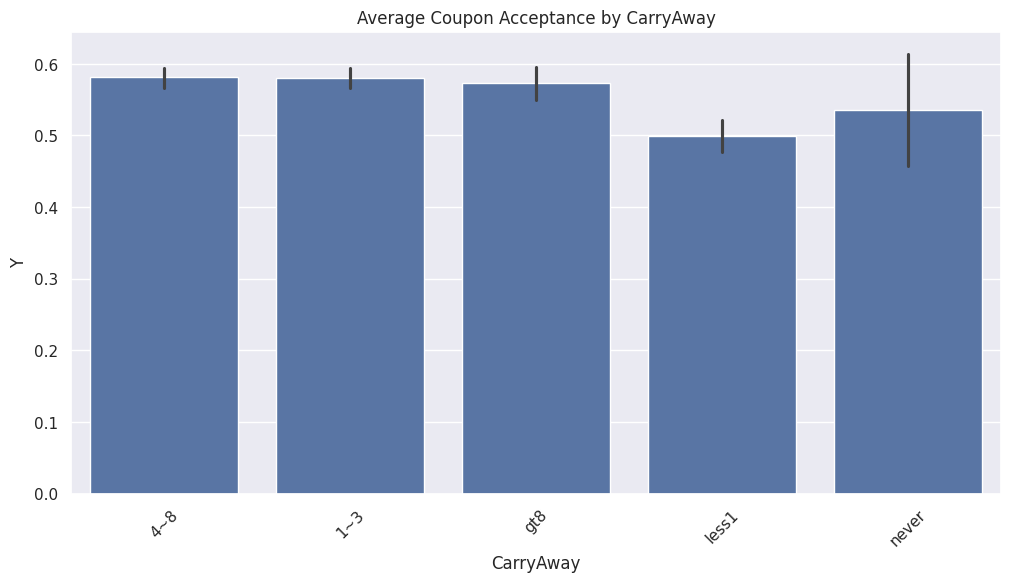

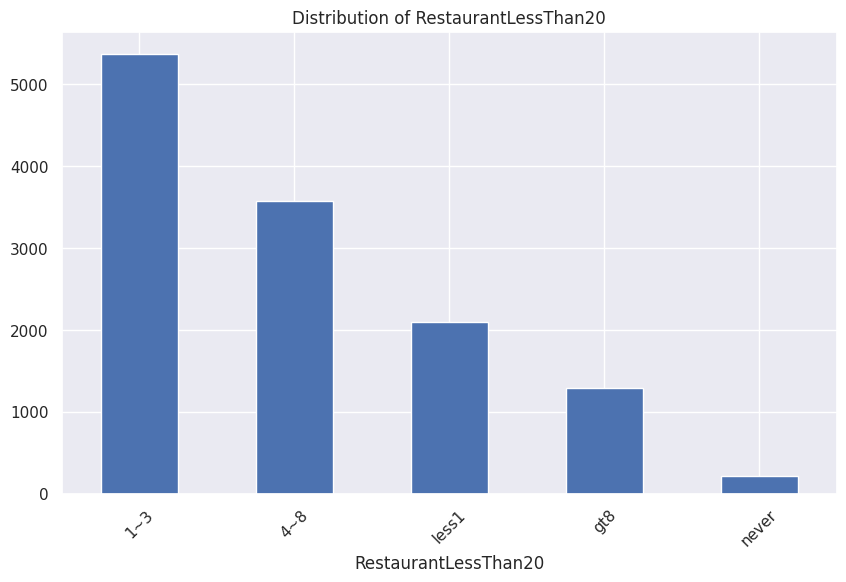

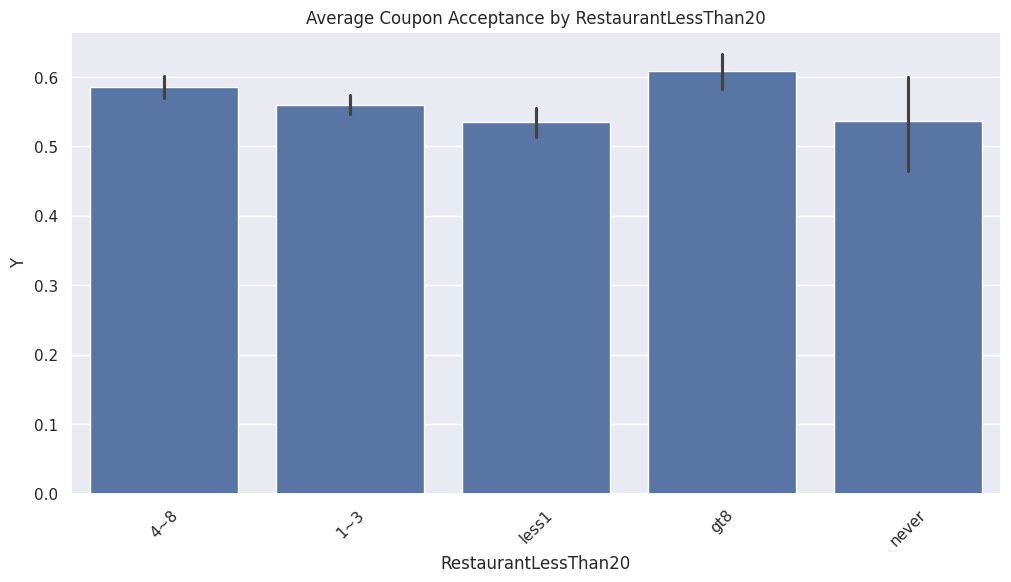

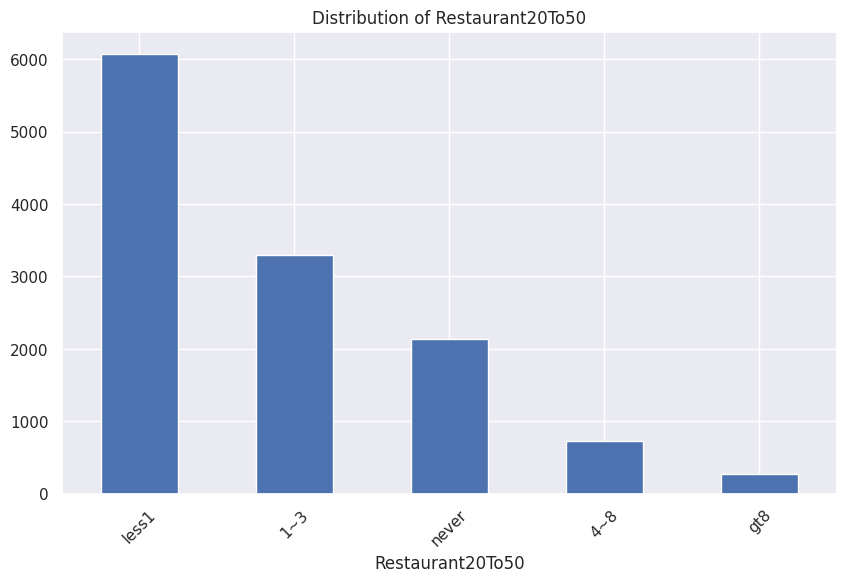

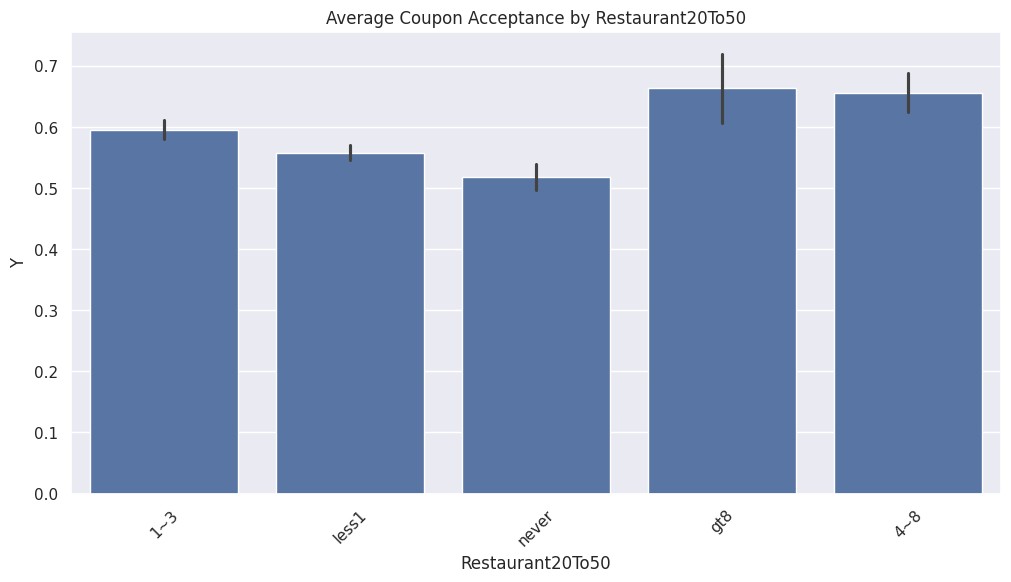

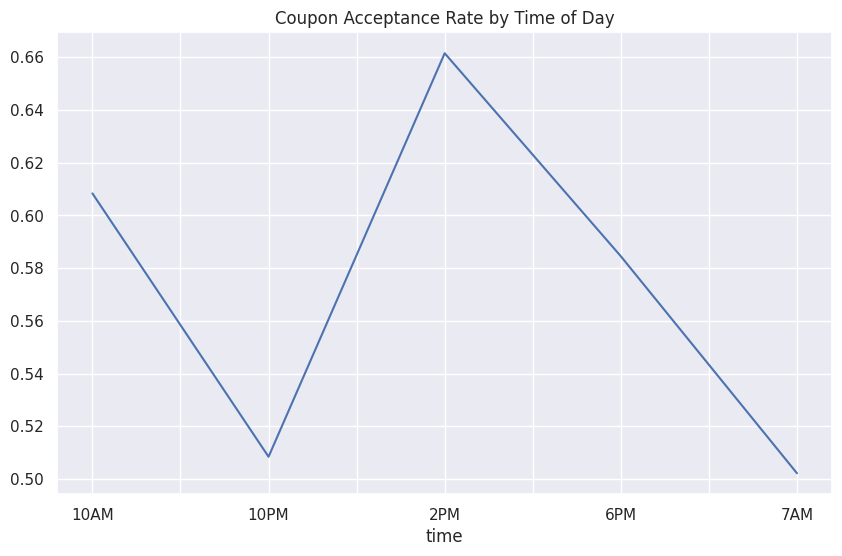

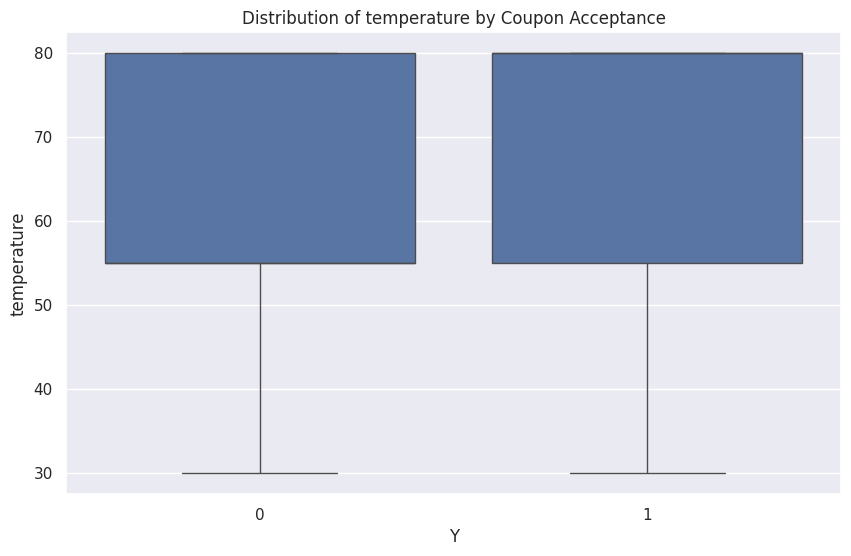

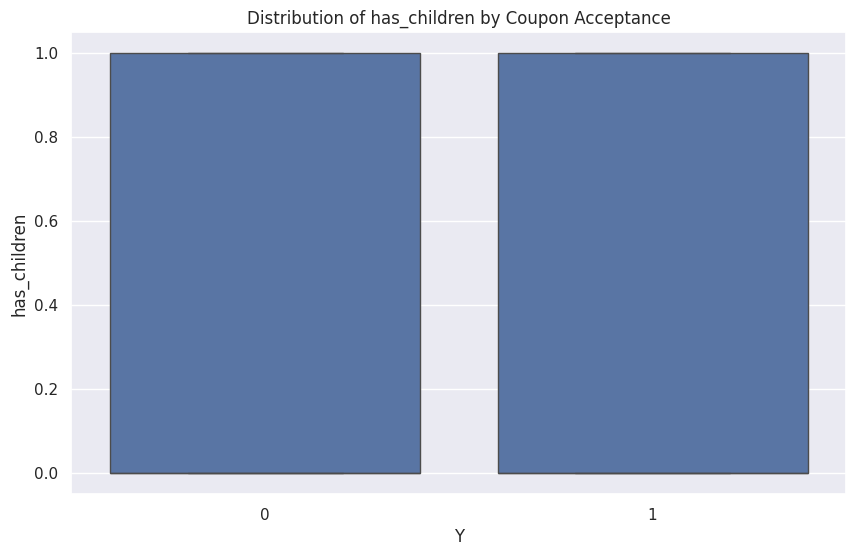

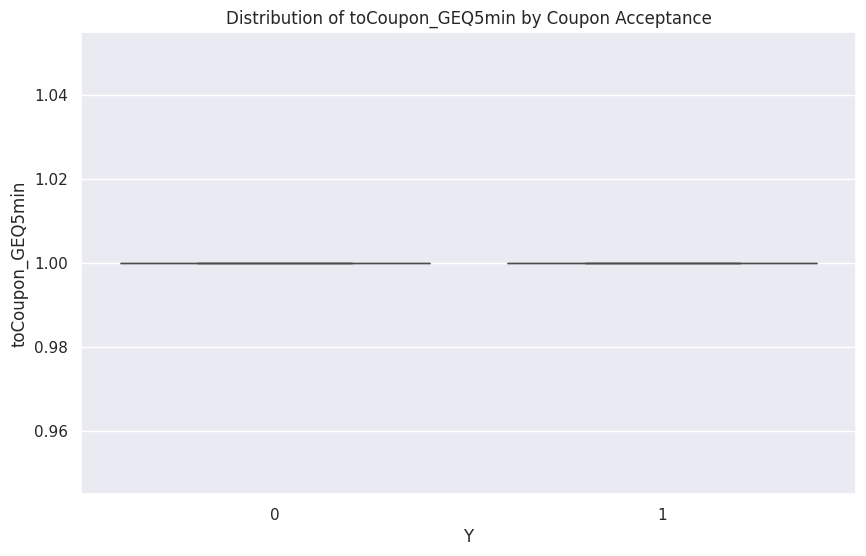

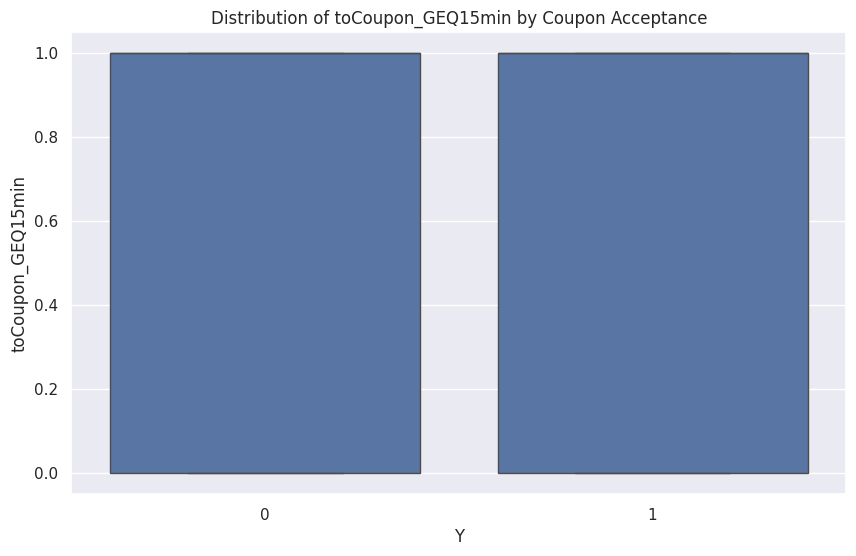

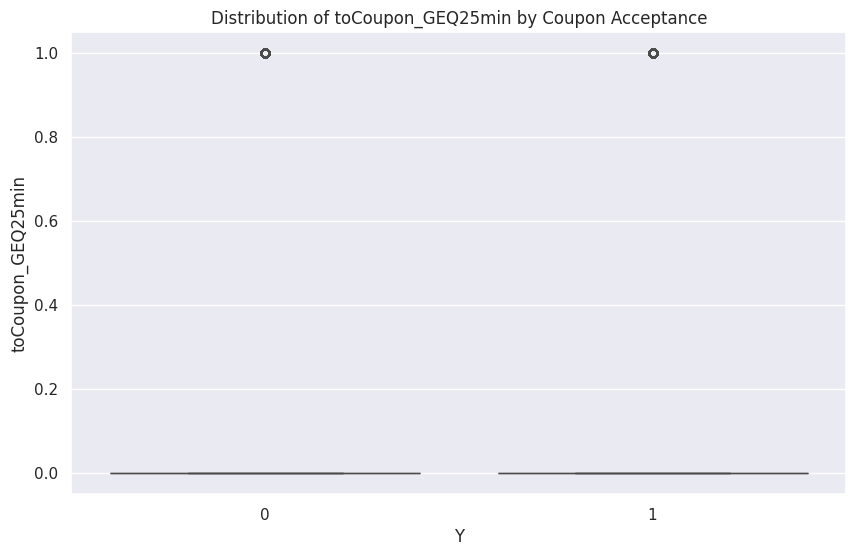

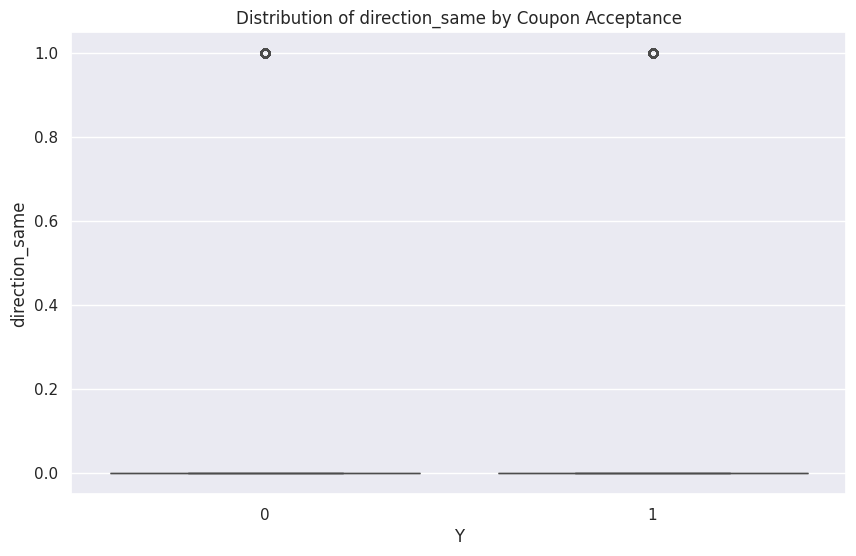

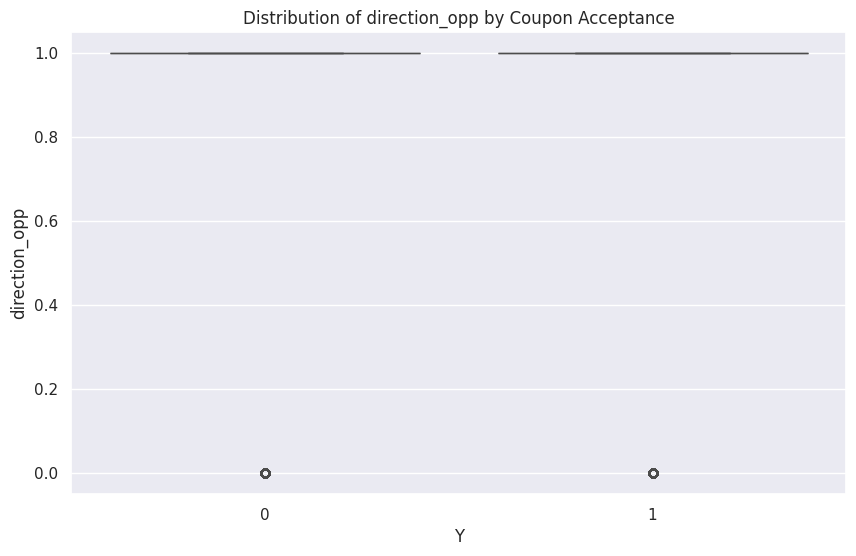

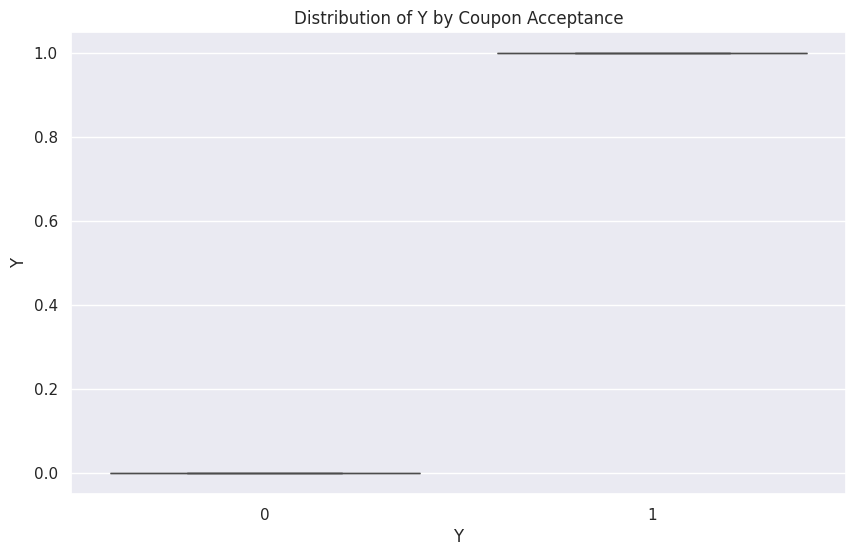


Key Statistics:
Overall Acceptance Rate: 0.5684326710816777

Acceptance Rate by destination:
destination
Home               0.506333
No Urgent Place    0.633774
Work               0.502212
Name: Y, dtype: float64

Acceptance Rate by passanger:
passanger
Alone        0.525804
Friend(s)    0.673438
Kid(s)       0.504970
Partner      0.595349
Name: Y, dtype: float64

Acceptance Rate by weather:
weather
Rainy    0.462810
Snowy    0.470463
Sunny    0.594796
Name: Y, dtype: float64

Acceptance Rate by time:
time
10AM    0.608352
10PM    0.508475
2PM     0.661523
6PM     0.584520
7AM     0.502212
Name: Y, dtype: float64

Acceptance Rate by coupon:
coupon
Bar                      0.410015
Carry out & Take away    0.735478
Coffee House             0.499249
Restaurant(20-50)        0.441019
Restaurant(<20)          0.707107
Name: Y, dtype: float64

Acceptance Rate by expiration:
expiration
1d    0.625582
2h    0.495977
Name: Y, dtype: float64

Acceptance Rate by gender:
gender
Female    0.54722

In [ ]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics of numerical columns
print("\nNumerical Columns Statistics:")
print(df.describe())

# Distribution of target variable (coupon acceptance)
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Y')  # Replace 'Y' with your target column name
plt.title('Distribution of Coupon Acceptance')
plt.show()

# Correlation analysis for numerical variables
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Analysis of categorical variables
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

    # Relationship between categorical variables and target
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x=col, y='Y')  # Replace 'Y' with your target column name
    plt.title(f'Average Coupon Acceptance by {col}')
    plt.xticks(rotation=45)
    plt.show()

# Time of day analysis (if time-related features exist)
if 'time' in df.columns:  # Replace 'time' with your time-related column
    plt.figure(figsize=(10, 6))
    df.groupby('time')['Y'].mean().plot(kind='line')
    plt.title('Coupon Acceptance Rate by Time of Day')
    plt.show()

# Feature distributions by acceptance
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Y', y=col)
    plt.title(f'Distribution of {col} by Coupon Acceptance')
    plt.show()

# Calculate acceptance rate by different categories
def acceptance_rate(group):
    return (group == 1).mean()

# Print key insights
print("\nKey Statistics:")
print("Overall Acceptance Rate:", df['Y'].mean())
for col in categorical_columns:
    print(f"\nAcceptance Rate by {col}:")
    print(df.groupby(col)['Y'].apply(acceptance_rate))

# Observaciones: EDA
